In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np

In [2]:
samples = [
    "2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    "2Mu2E_100GeV_5p0GeV_200mm_disp",
    "2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    "2Mu2E_1000GeV_0p25GeV_1p0mm_disp",

    "TTJets_disp",
    "QCD_Pt80To120_disp", 
    # "QCD_Pt120To170",
    "QCD_Pt170To300_disp", 
    "QCD_Pt300To470_disp",
    "QCD_Pt470To600_disp", 
    "QCD_Pt600To800_disp", 
    # "QCD_Pt800To1000",
    "QCD_Pt1000_disp", 
    "DYJetsToMuMu_M10to50_disp",
    "DYJetsToMuMu_M50_disp", 
]

In [3]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "output_" + sample + ".coffea"
        try: 
            output = coffea.util.load(filename)
            print("Successfully opened file")        
            # out[sample] = output["out"][sample]
            out[sample] = output["out"][sample.removesuffix("_disp")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for sample 2Mu2E_100GeV_5p0GeV_4p0mm_disp
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0GeV_200mm_disp
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_0p02mm_disp
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_1p0mm_disp
Successfully opened file
Loading file for sample TTJets_disp
Successfully opened file
Loading file for sample QCD_Pt80To120_disp
Successfully opened file
Loading file for sample QCD_Pt170To300_disp
Successfully opened file
Loading file for sample QCD_Pt300To470_disp
Successfully opened file
Loading file for sample QCD_Pt470To600_disp
Successfully opened file
Loading file for sample QCD_Pt600To800_disp
Successfully opened file
Loading file for sample QCD_Pt1000_disp
Successfully opened file
Loading file for sample DYJetsToMuMu_M10to50_disp
Successfully opened file
Loading f

In [9]:
from cycler import cycler

channels = ["baseNoLj_No_Muon_Constraint", "baseNoLj_Even_Muon_Charge", "baseNoLj_Only_Two_Muon", "baseNoLj_Two_Ormore_Muon", 
            "baseNoLj_Even_Muon_Charge_Displacement", "baseNoLj_Only_Two_Muon_Displacement", "baseNoLj_Two_Ormore_Muon_Displacement"]

legend = [
    "Baseline", 
    "Even Charge", 
    "Muon == 2", 
    "Muon >= 2", 
    "Even Charge + Displacement", 
    "Muon == 2 + Displacement",
    "Muon >= 2 + Displacement"
]

colors = [
    "r",  
    "g",  
    "b",  
    "darkorange",
    "purple",  
    "cyan",
]

plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

In [5]:
def plot_ratio_wrapper(
    out,
    sample_name,
    hist_name,
    channels,
    legend,
    hist_range,
    text_x,
    text_y=3,
):

    hists = out[sample_name]["hists"][hist_name]

    num_list = [
        hists[ch, hist_range] for ch in channels[1:]
    ]

    den = hists[channels[0], hist_range]

    utilities.plot_ratio(
        num_list,
        den,
        legend=legend,
        ylabel="Arbitrary Units",
        text=""
    )

    plt.text(text_x, text_y, sample_name.replace("_disp", ""))

In [6]:
def sum_bgs_hist(bgs_list, histogram_name, channel_name):
    """
    Sum histograms for a list of backgrounds.
    """
    summed_hist = None
    
    for x in bgs_list:
        # print(x)
        hist = out[x]["hists"][histogram_name][channel_name, :]
        
        if summed_hist is None:
            summed_hist = hist.copy()
        else:
            summed_hist += hist
    
    return summed_hist

In [7]:
import math
import mplhep as hep

def plot_ratio_panels(samples, histname, channels, legend, **kwargs):

    n_panels = len(samples)
    if n_panels == 0:
        raise ValueError("Empty Sample!")
    if len(channels) != len(legend):
        raise ValueError("Length of channels and legend needs to same")

    ncols = kwargs.get("ncols", 3)
    n_sample_rows = math.ceil(n_panels / ncols)
    nrows = 2 * n_sample_rows

    ylabel = kwargs.get("ylabel", None)
    eff_ylim = kwargs.get("eff_ylim", (0, 1.2))
    ylims = kwargs.get("ylims", [None] * n_panels)
    flow = kwargs.get("flow", "none")
    logy = kwargs.get("logy", False)
    main_histtype = kwargs.get("main_histtype", None)
    ratio_histtype = kwargs.get("ratio_histtype", "errorbar")

    titles = kwargs.get(
        "titles",
        [s.replace("QCD_", "").replace("DY_", "").replace("_disp", "") for s in samples]
    )

    figsize = kwargs.get("figsize", (14 * ncols, 9 * n_sample_rows + 5 * n_sample_rows))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex='col',
        squeeze=False,
        gridspec_kw={
            'height_ratios': [3, 1] * n_sample_rows,
            'hspace': 0,
            'wspace': 0.25
        }
    )

    for i, sample in enumerate(samples):
        col = i % ncols
        block = i // ncols

        ax1 = axes[2 * block, col]
        ax2 = axes[2 * block + 1, col]

        h = out[sample]["hists"][histname]

        den = h[channels[0], :]
        nums = [h[ch, :] for ch in channels[1:]]
        plt.sca(ax1)

        main_kwargs = dict(flow=flow, color='k', label=legend[0])
        if main_histtype is not None:
            main_kwargs["histtype"] = main_histtype
        hep.histplot(den, **main_kwargs)

        for j, x in enumerate(nums):
            num_kwargs = dict(flow=flow, label=legend[j + 1])
            if main_histtype is not None:
                num_kwargs["histtype"] = main_histtype
            hep.histplot(x, **num_kwargs)

        ax1.legend(fontsize=20)
        ax1.set_title(titles[i])

        if ylims[i] is not None:
            ax1.set_ylim(ylims[i])

        if logy:
            ax1.set_yscale("log")

        if col == 0 and ylabel is not None:
            ax1.set_ylabel(ylabel)
        plt.sca(ax2)

        for x in nums:
            eff, errors = utilities.get_eff_hist(x, den)
            hep.histplot(
                eff,
                histtype=ratio_histtype,
                yerr=errors
            )

        if col == 0:
            ax2.set_ylabel("Efficiency")

        ax2.set_ylim(*eff_ylim)

    total_slots = n_sample_rows * ncols
    for i in range(n_panels, total_slots):
        col = i % ncols
        block = i // ncols
        axes[2 * block, col].set_visible(False)
        axes[2 * block + 1, col].set_visible(False)

    plt.tight_layout()
    return fig, axes

## LJ muon cut test version 2
### We conclude that `number of muons in LJ == 2` is already better than the charge sum constraint in the previous notebook.
### Now, we are looking into a more specific study 
### Target channel is whether `number of muons in LJ == 2 or >= 2`
### Also, we included our latest displacement cut here so we can determine which cut choice is better after applying the displacement cut

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

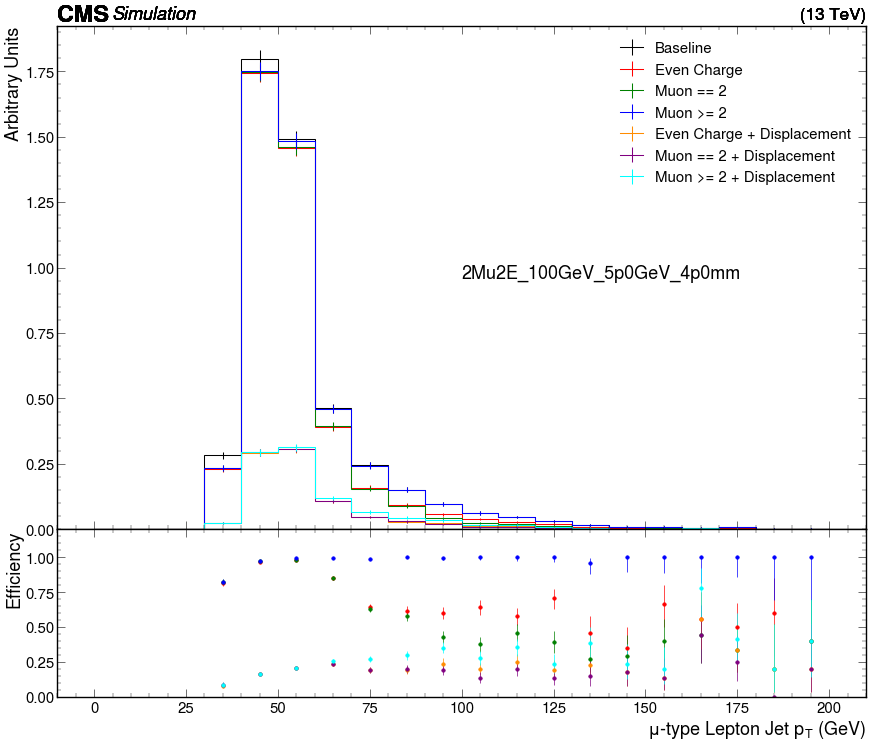

In [10]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    hist_name="mu_lj_pt",
    channels=channels,
    legend=legend,
    hist_range=slice(None, 200j), 
    text_x=100
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

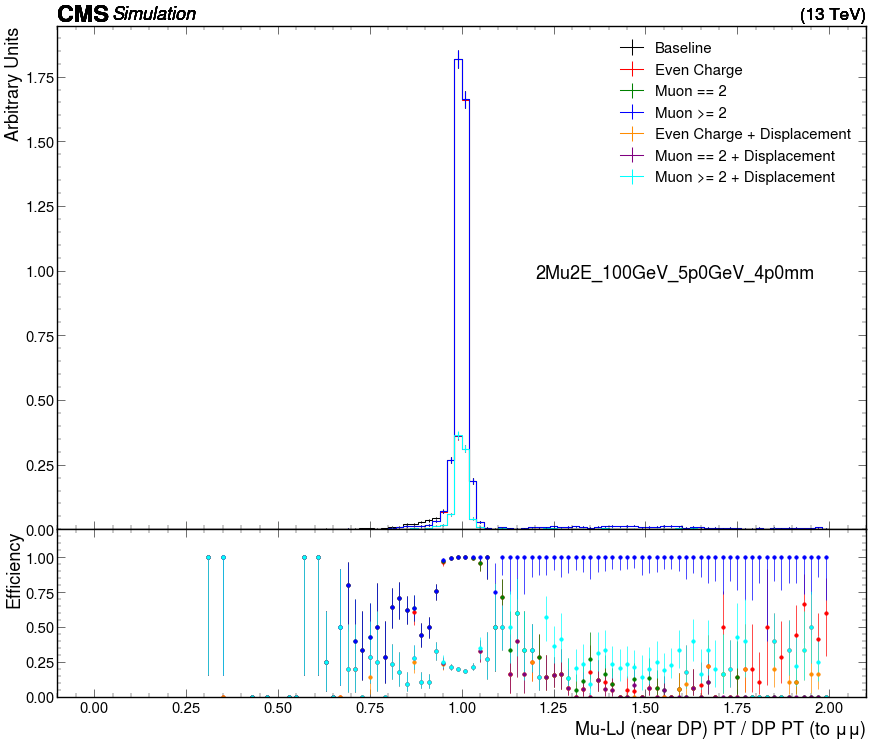

In [11]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    hist_name="muLj_genA_ptRatio",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=1.2
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

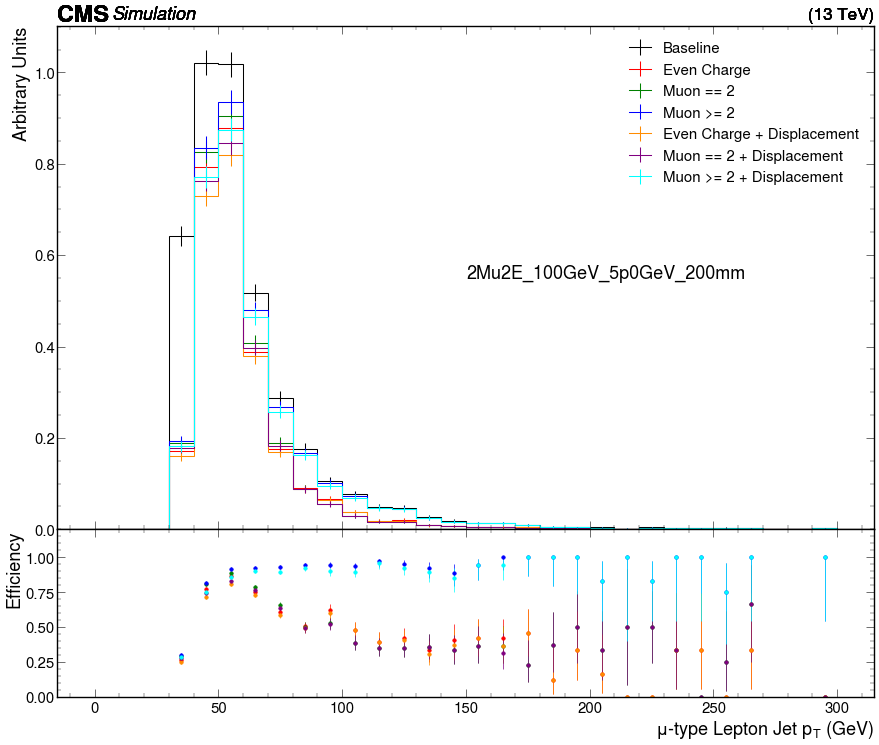

In [12]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_100GeV_5p0GeV_200mm_disp",
    hist_name="mu_lj_pt",
    channels=channels,
    legend=legend,
    hist_range=slice(None, 300j), 
    text_x=150
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

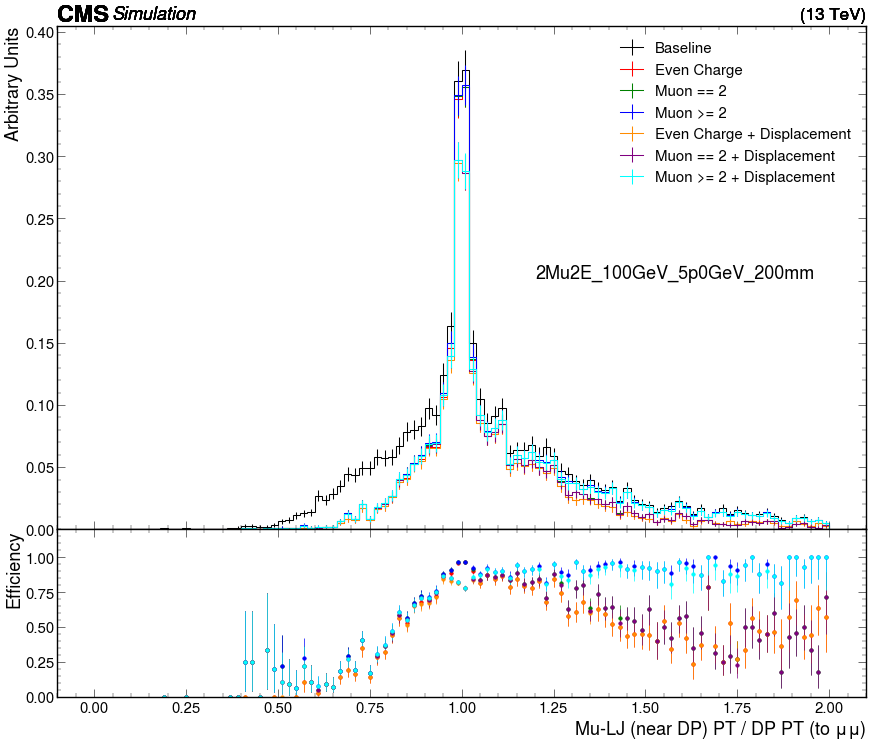

In [13]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_100GeV_5p0GeV_200mm_disp",
    hist_name="muLj_genA_ptRatio",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=1.2
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

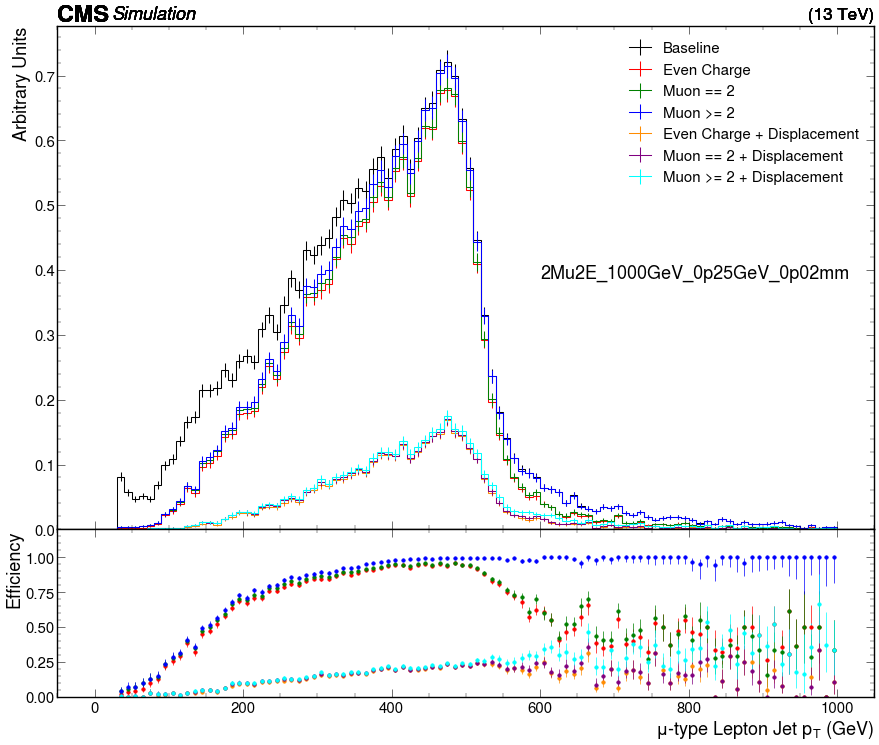

In [14]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    hist_name="mu_lj_pt",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=600
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

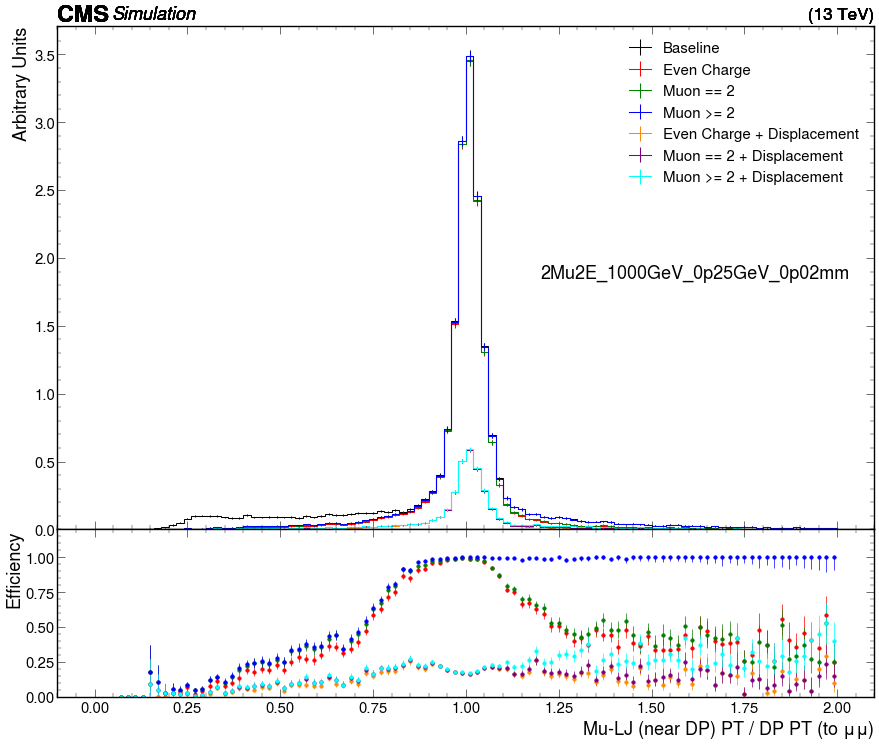

In [15]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    hist_name="muLj_genA_ptRatio",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=1.2
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

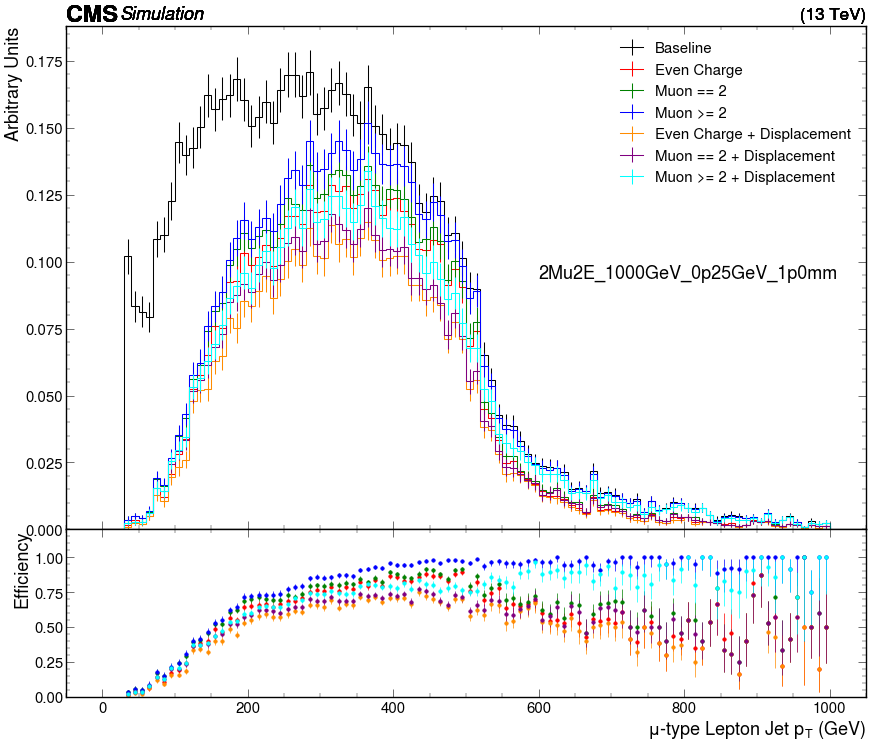

In [16]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_1000GeV_0p25GeV_1p0mm_disp",
    hist_name="mu_lj_pt",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=600
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

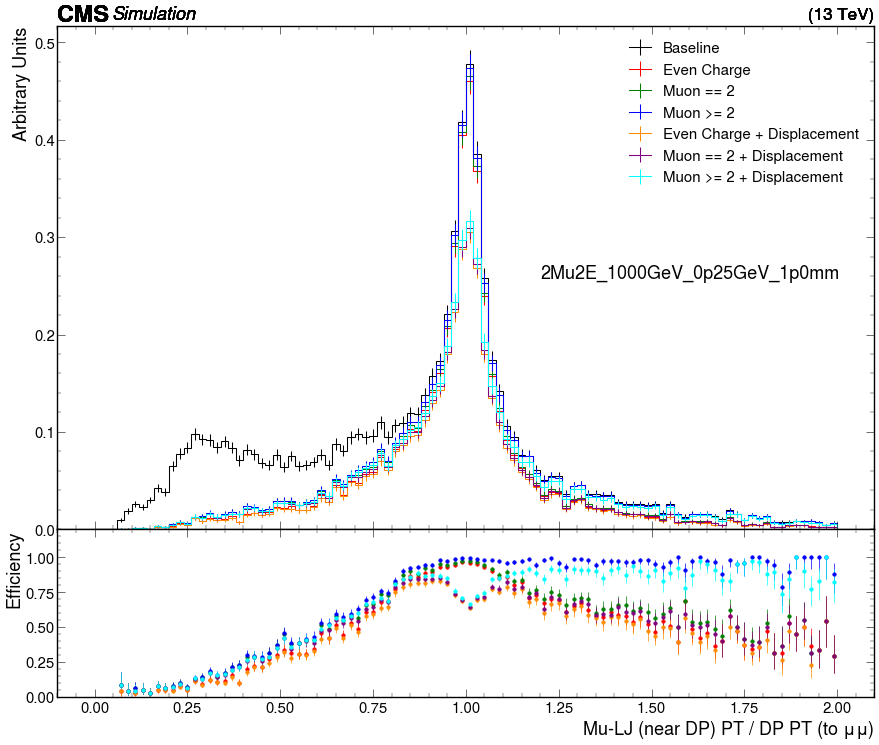

In [17]:
plot_ratio_wrapper(
    out=out,
    sample_name="2Mu2E_1000GeV_0p25GeV_1p0mm_disp",
    hist_name="muLj_genA_ptRatio",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=1.2
)

### Same variable choice as previous.
#### Definitely the efficiency of `number of muons >= 2` is better than `number of muons == 2` channel. No doubt.
#### The question is, do we really need to include the muon >= 3 case? Because technically, it's not our final state choice.
#### Let's say we keep those channels for follow-up analysis at the moment.
#### Lesson from here. As we expected, the promptly decaying signal clearly shows a signal loss with the displacement cut. 
#### But, for longer Lxy samples, it's showing not much difference before & after the displacement cut.
#### This is a good sign and agree with our analysis strategy!
#### Now, move on to bkgs

In [18]:
QCD = [   
    "QCD_Pt80To120_disp",
    # "QCD_Pt120To170",
    "QCD_Pt170To300_disp",
    "QCD_Pt300To470_disp",
    "QCD_Pt470To600_disp",
    "QCD_Pt600To800_disp",
    # "QCD_Pt800To1000",
    "QCD_Pt1000_disp",
]

DY = [
    "DYJetsToMuMu_M10to50_disp", 
    "DYJetsToMuMu_M50_disp", 
]

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

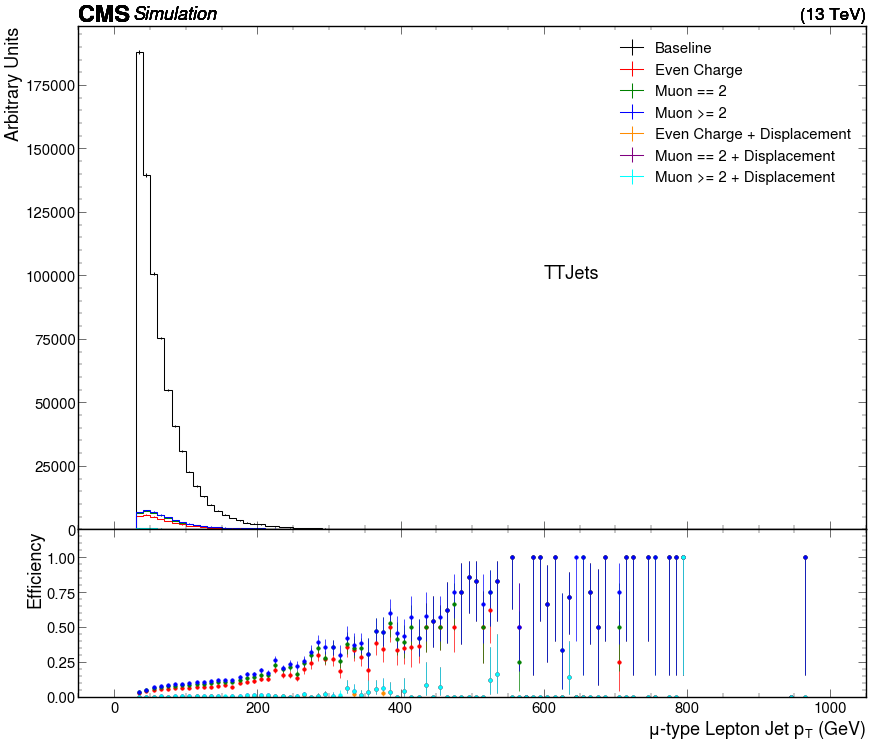

In [19]:
plot_ratio_wrapper(
    out=out,
    sample_name="TTJets_disp",
    hist_name="mu_lj_pt",
    channels=channels,
    legend=legend,
    hist_range=slice(None, None), 
    text_x=600
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

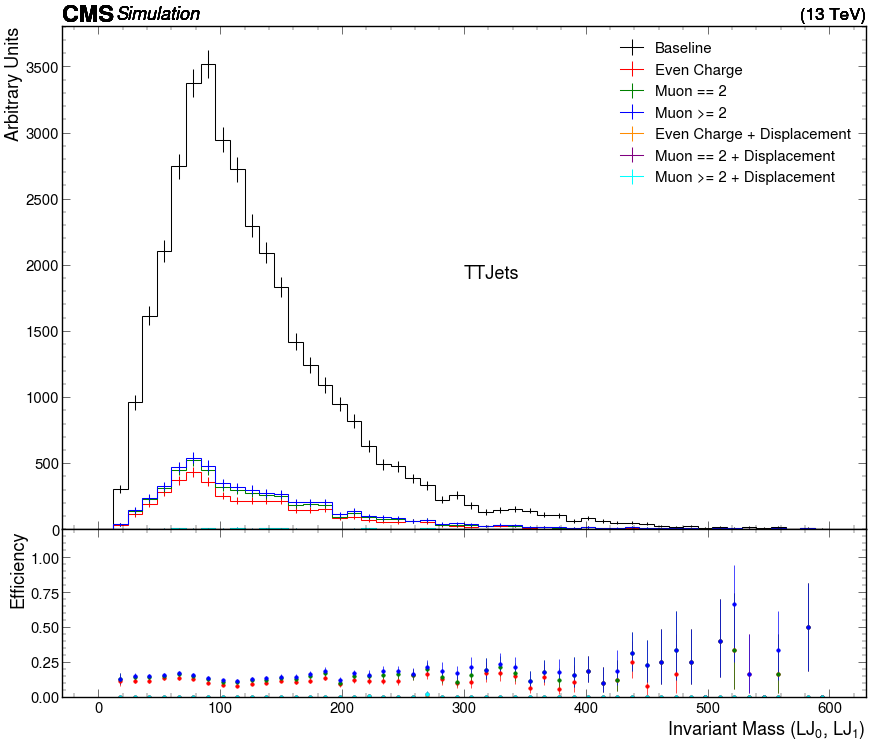

In [20]:
plot_ratio_wrapper(
    out=out,
    sample_name="TTJets_disp",
    hist_name="mulj_egmlj_invmass",
    channels=channels,
    legend=legend,
    hist_range=slice(None, 600j), 
    text_x=300
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

(<Figure size 2100x1400 with 12 Axes>,
 array([[<Axes: title={'center': 'Pt80To120'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Arbitrary Units'>,
         <Axes: title={'center': 'Pt170To300'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>,
         <Axes: title={'center': 'Pt300To470'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>],
        [<Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Efficiency'>,
         <Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>,
         <Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>],
        [<Axes: title={'center': 'Pt470To600'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Arbitrary Units'>,
         <Axes: title={'center': 'Pt600To800'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>,
         <Axes: title={'center': 'Pt1000'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>],
        [<Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Efficiency'>,
         <Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV

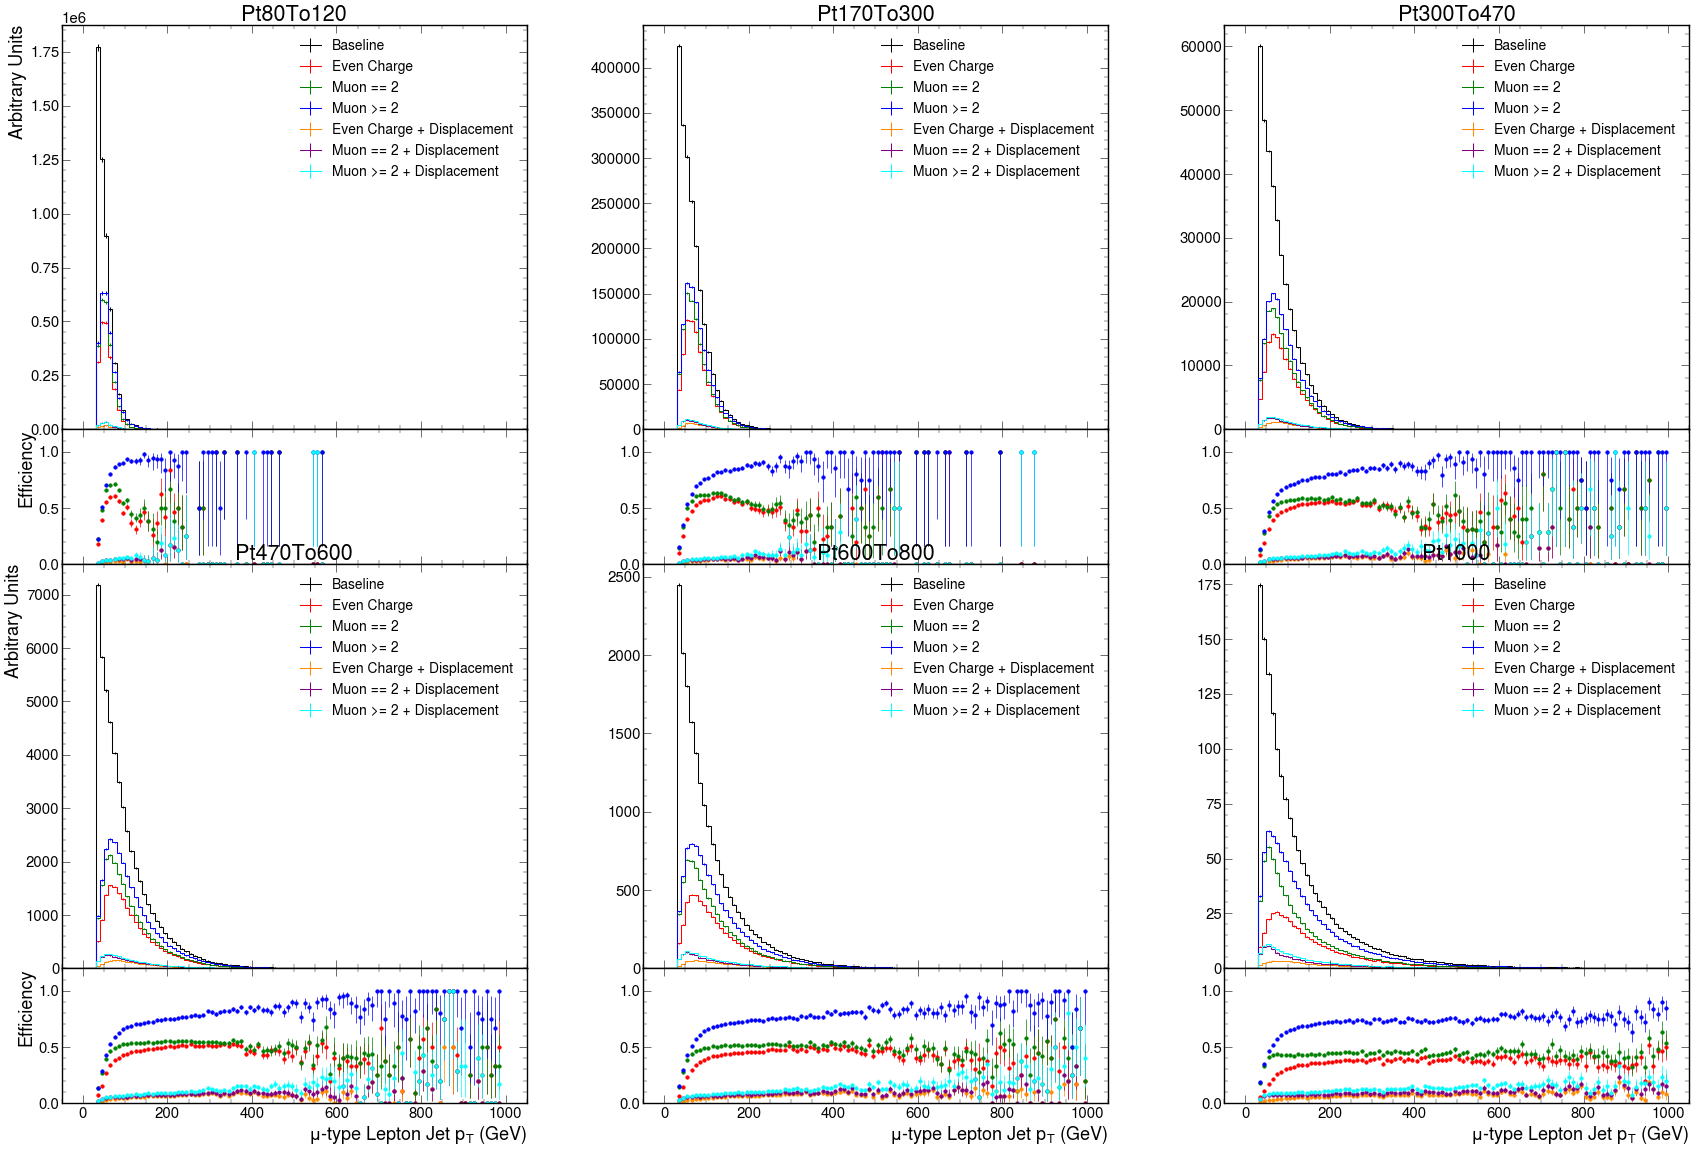

In [21]:
plot_ratio_panels(
    QCD,
    histname="mu_lj_pt",
    channels=channels,
    legend=legend,
    ylabel="Arbitrary Units",
    eff_ylim=(0, 1.2),
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

ValueError: Found numerator larger than denominator while calculating binomial uncertainty

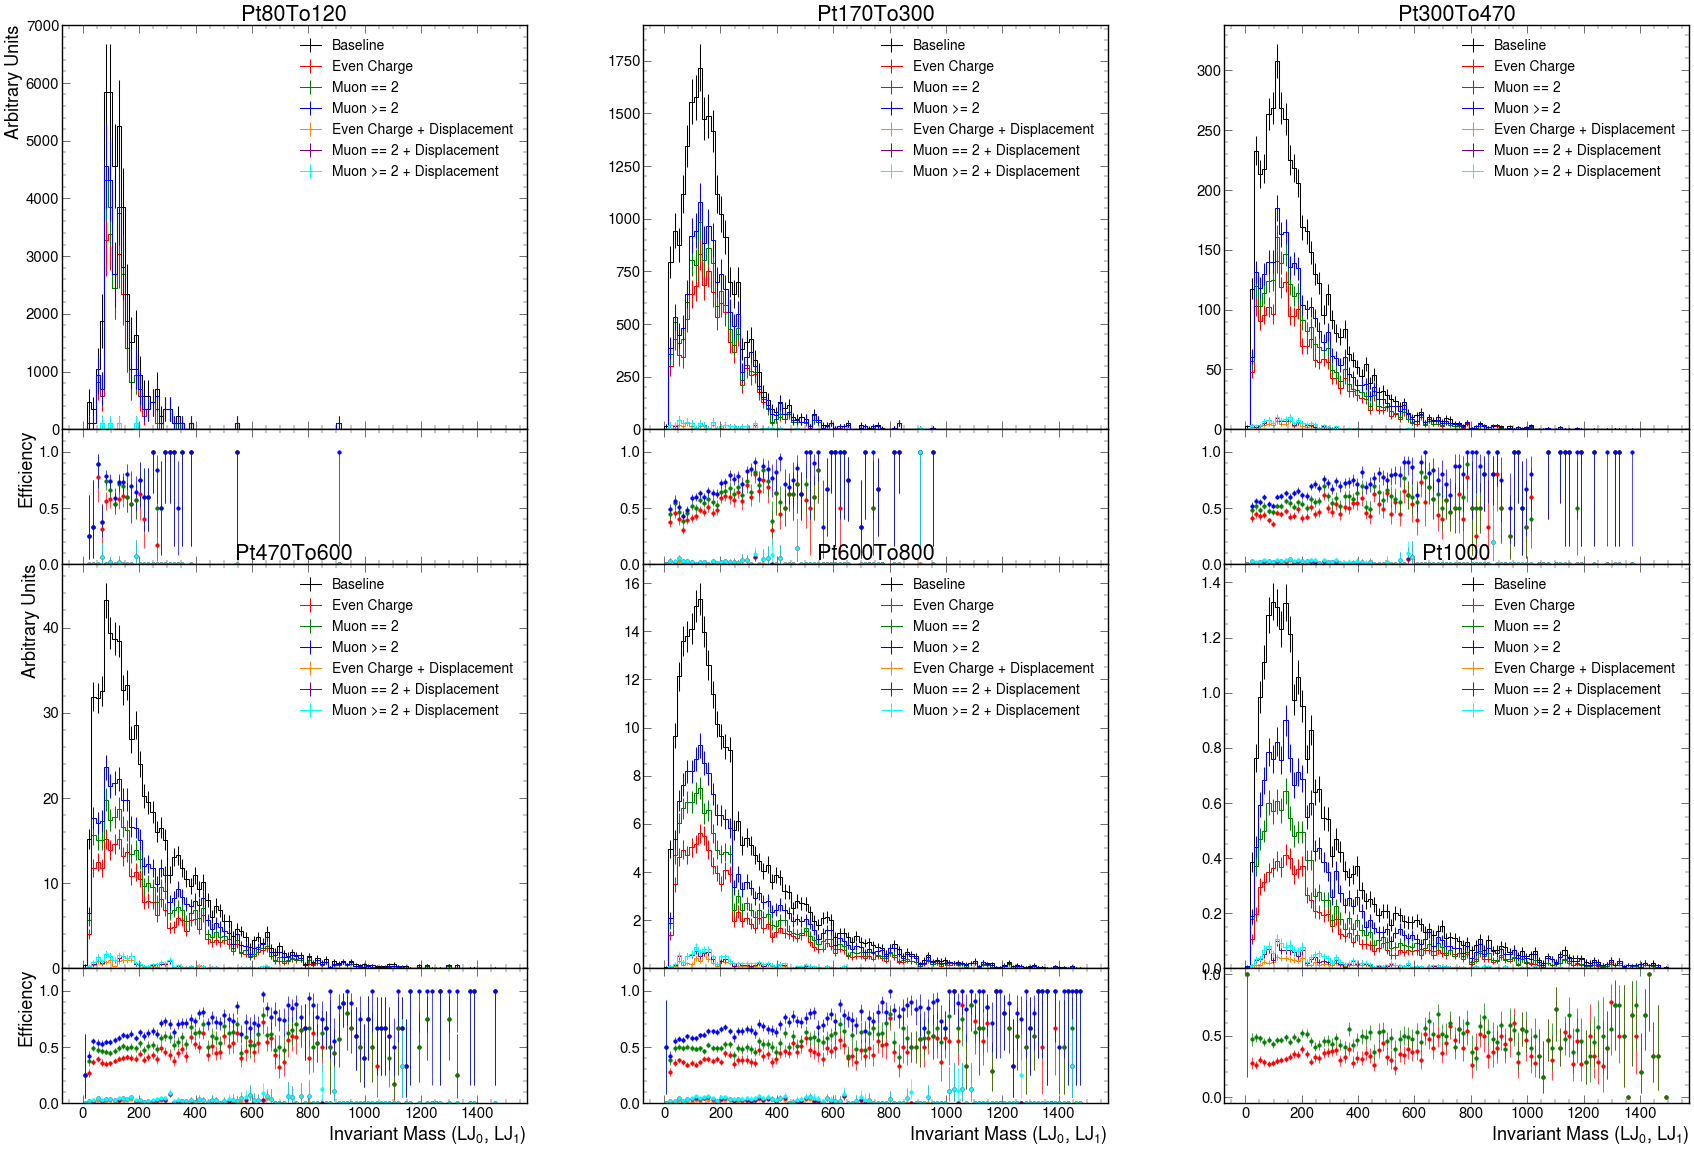

In [22]:
plot_ratio_panels(
    QCD,
    histname="mulj_egmlj_invmass",
    channels=channels,
    legend=legend,
    ylabel="Arbitrary Units",
    eff_ylim=(0, 1.2),
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

(<Figure size 2100x700 with 6 Axes>,
 array([[<Axes: title={'center': 'DYJetsToMuMu_M10to50'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Arbitrary Units'>,
         <Axes: title={'center': 'DYJetsToMuMu_M50'}, xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>,
         <Axes: >],
        [<Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)', ylabel='Efficiency'>,
         <Axes: xlabel='$\\mu$-type Lepton Jet $p_T$ (GeV)'>, <Axes: >]],
       dtype=object))

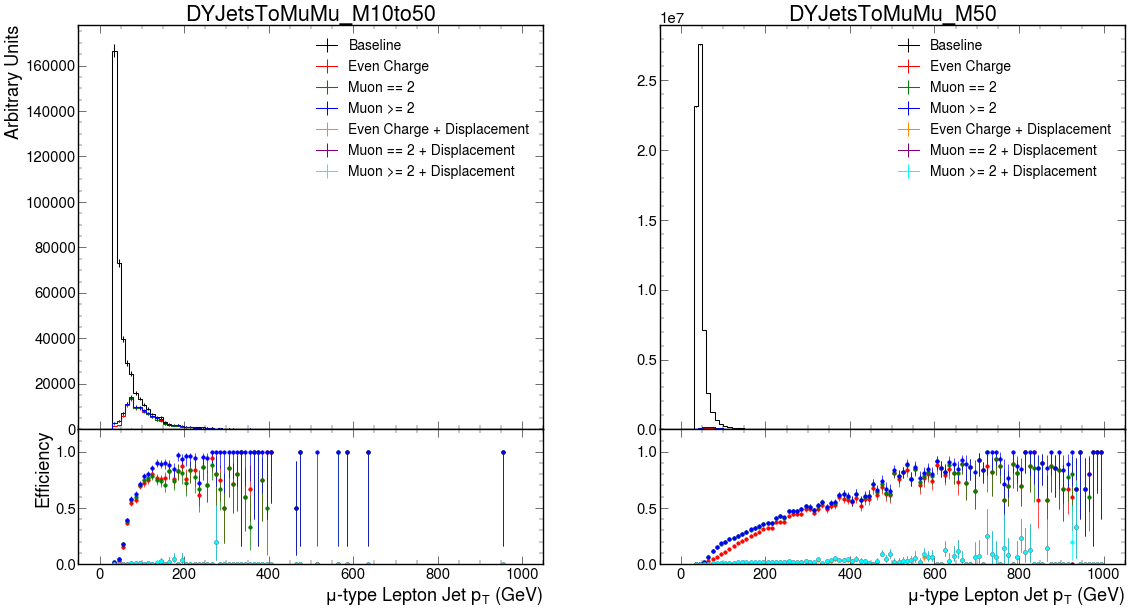

In [23]:
plot_ratio_panels(
    DY,
    histname="mu_lj_pt",
    channels=channels,
    legend=legend,
    ylabel="Arbitrary Units",
    eff_ylim=(0, 1.2),
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: Runtime

(<Figure size 2100x700 with 6 Axes>,
 array([[<Axes: title={'center': 'DYJetsToMuMu_M10to50'}, xlabel='Invariant Mass ($LJ_{0}$, $LJ_{1}$)', ylabel='Arbitrary Units'>,
         <Axes: title={'center': 'DYJetsToMuMu_M50'}, xlabel='Invariant Mass ($LJ_{0}$, $LJ_{1}$)'>,
         <Axes: >],
        [<Axes: xlabel='Invariant Mass ($LJ_{0}$, $LJ_{1}$)', ylabel='Efficiency'>,
         <Axes: xlabel='Invariant Mass ($LJ_{0}$, $LJ_{1}$)'>, <Axes: >]],
       dtype=object))

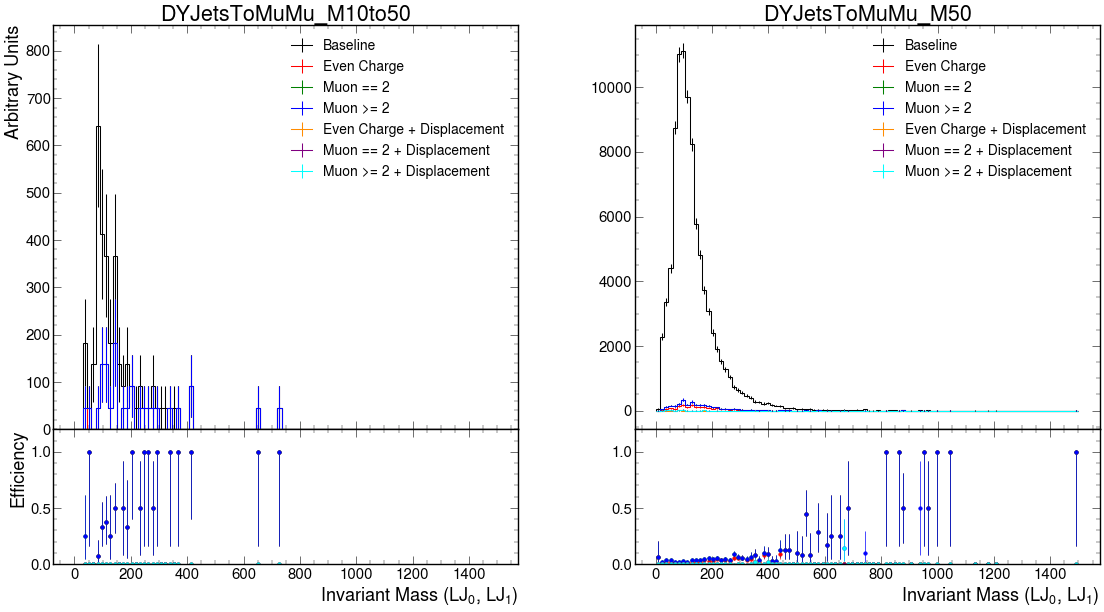

In [24]:
plot_ratio_panels(
    DY,
    histname="mulj_egmlj_invmass",
    channels=channels,
    legend=legend,
    ylabel="Arbitrary Units",
    eff_ylim=(0, 1.2),
)

### Nice! The displacement cut killed most of the background events!
### Some plots have a negative weight effect, but still, we learned a few things here!
#### 1. `Muon >= 2` saves more stats. But we'll take this for follow-up analysis someday
#### 2. Displacement cut might hurt the decaying signal, but barely touch the displaced signal. While most of the backgrounds were just killed by the displacement cut.
#### So far, our final cut choice will be `muon >=2 + displacement cut` channel (Cyan color)